In [21]:
import joblib
import os
import sys
import yaml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
config2_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus.yaml"
with open(config2_path, "r") as fb:
    annot2_dict = yaml.safe_load(fb)
protocol_cols2 = annot2_dict["protocol_columns"]

In [4]:
config3_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(config3_path, "r") as fb:
    annot3_dict = yaml.safe_load(fb)
protocol_cols3 = annot3_dict["protocol_columns"]

In [7]:
constraints2_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(constraints2_config_path, "r") as fb:
    constraints2_config = yaml.safe_load(fb)
ubound2_dict = constraints2_config["ubound_dict"]
lbound2_dict = constraints2_config["lbound_dict"]


In [8]:
constraints3_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop3.yaml"
with open(constraints3_config_path, "r") as fb:
    constraints3_config = yaml.safe_load(fb)
ubound3_dict = constraints3_config["ubound_dict"]
lbound3_dict = constraints3_config["lbound_dict"]


In [12]:
def get_opt_df(
    res_base_dir
):
    all_runs = []

    opt_modes_list = os.listdir(res_base_dir)

    for opt_leaf_dir in opt_modes_list:
        opt_dir = os.path.join(res_base_dir, opt_leaf_dir)
        cts_list = os.listdir(opt_dir)

        for ct_leaf_dir in cts_list:
            ct_dir = os.path.join(opt_dir, ct_leaf_dir)
            runs_list = os.listdir(ct_dir)

            for run_leaf_dir in runs_list:
                run_dir = os.path.join(ct_dir, run_leaf_dir)
                csv_path = os.path.join(run_dir, "candidates.csv")            
                all_runs.append(
                    {
                        "target_ct": ct_leaf_dir,
                        "run_id": run_leaf_dir,
                        "opt_id": opt_leaf_dir,
                        "csv_path": csv_path,
                    }
                )
    def _load_run(run_dict):
        target_ct = run_dict["target_ct"]
        run_id = run_dict["run_id"]
        opt_id = run_dict["opt_id"]
        csv_path = run_dict["csv_path"]

        df = pd.read_csv(csv_path)
        df["run_id"] = run_id
        df["opt_id"] = opt_id
        df["target_ct"] = target_ct
        return df
        
    n_jobs = 100
    data = joblib.Parallel(n_jobs=n_jobs)(joblib.delayed(_load_run)(run_dict) for run_dict in all_runs)
    return pd.concat(data, ignore_index=True)

In [15]:
res_base_dir2 = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop2p5_replicate"
opt_df2 = get_opt_df(res_base_dir2)
opt_df2

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,EryPro:2026-06-26_04-11-58_cee7e426:0,12.124698,2.182126,84.65543,0.000000,0.862212,0.000000,0.000000,0.006725,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EryPro:2026-06-26_04-11-58_cee7e426:1,2.807606,0.016716,289.35630,175.749700,0.000000,0.000000,116.696170,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EryPro:2026-06-26_04-11-58_cee7e426:2,10.091269,2.569805,550.93555,782.041000,0.045200,47.781437,0.066810,0.000000,0.001518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,EryPro:2026-06-26_04-11-58_cee7e426:3,9.844760,2.468653,774.40030,0.063012,0.552813,47.939167,0.052818,0.296393,0.015844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,EryPro:2026-06-26_04-11-58_cee7e426:4,9.687686,2.489527,824.40380,1212.362300,0.025199,56.669476,0.000000,0.032299,0.015634,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152045,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:45,10.852804,2.487143,551.91125,773.857000,0.000000,48.539486,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152046,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:46,11.335658,2.366785,1005.68230,578.002700,0.000000,24.263077,0.094563,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152047,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:47,10.607610,1.946655,742.47614,1444.148200,0.000000,39.061016,0.000000,0.000000,1.770090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152048,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:48,10.221303,2.617736,347.98157,645.587950,0.000000,43.864124,0.000000,0.000000,0.040813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
res_base_dir3 = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop3_replicate"
opt_df3 = get_opt_df(res_base_dir3)
opt_df3

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml],cfg:constraints:ubound_dict:il7_[ng_ml],cfg:constraints:ubound_dict:mcsf_[ng_ml],cfg:constraints:ubound_dict:ly_cocktail_[ul/well]
0,CD16Mono:2026-06-26_23-29-58_dfbf9997:0,4.502639,0.184500,4.242442,0.197834,1.214640,0.487637,8.061746,0.179712,0.006153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CD16Mono:2026-06-26_23-29-58_dfbf9997:1,10.106312,2.453917,738.088200,1430.027600,0.000000,49.336456,0.088904,0.131064,0.122932,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CD16Mono:2026-06-26_23-29-58_dfbf9997:2,10.268727,2.255093,66.239860,0.060196,0.091318,47.117905,0.074269,0.623657,0.054582,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CD16Mono:2026-06-26_23-29-58_dfbf9997:3,9.620847,2.409060,259.914370,957.807860,0.088218,55.726196,0.377347,0.000000,11.627491,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CD16Mono:2026-06-26_23-29-58_dfbf9997:4,9.052049,2.468425,1285.206400,1184.954100,0.069181,46.737404,0.000000,0.091902,0.111592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65695,CD14Mono:2026-06-26_20-26-55_f1d5b99e:45,10.086290,1.507519,369.848420,1088.289400,0.000000,40.052810,0.000000,0.475927,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65696,CD14Mono:2026-06-26_20-26-55_f1d5b99e:46,10.640902,2.595452,760.161600,0.427938,1.162259,4.370168,0.000000,0.000000,0.204198,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65697,CD14Mono:2026-06-26_20-26-55_f1d5b99e:47,11.415030,1.700545,721.534400,921.651370,0.505301,27.234516,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65698,CD14Mono:2026-06-26_20-26-55_f1d5b99e:48,10.193460,2.154316,1144.129400,0.000000,1.798966,55.886826,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
def filter_opt_results(candidates_df, lbound_dict, ubound_dict,  margin = 0.1):
    # ----  Target Markers Loop ----
    print("---- Filtering Results ----")
    # define mask for all columns
    marker_mask = np.full(candidates_df.shape[0], True)

    # ----  Protocol Columns Loop ----
    for col, col_ubound in ubound_dict.items():
        # get col bounds
        col_lbound = lbound_dict[col]
        print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

        # get col values and mask
        col_values = candidates_df[col]
        col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
        col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

        # get masks for current column
        old_mask = marker_mask
        lbound_marker_mask = marker_mask & col_mask_lbound_mask
        ubound_marker_mask = marker_mask & col_mask_ubound_mask
        marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

        # get number of solutions
        n_previously_accepted_solutions = old_mask.sum()
        n_accepted_solutions = marker_mask.sum()
        n_solutions_passing_ubound = col_mask_ubound_mask.sum()
        n_solutions_passing_lbound = col_mask_lbound_mask.sum()
        n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
        n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
        print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
        print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


        # write values for constraint on current column
        candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
        candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

    # write values for all constraints
    n_all_solutions = candidates_df.shape[0]
    n_accepted_solutions = marker_mask.sum()
    candidates_df["passes_constraints:all"] = marker_mask

    print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")
    return candidates_df

In [31]:
opt_df2 = filter_opt_results(opt_df2, lbound2_dict, ubound2_dict)
opt_df2_filt = opt_df2[opt_df2["passes_constraints:all"]]
opt_df2_filt.shape[0] / opt_df2.shape[0]

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 152050 ---
			 --- Number Currently Accepted Solutions 137141 ---
			 --- Number of Solution Satisfying Upper Bound 137141 ---
			 --- Number of Solution Satisfying Lower Bound 152050 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 137141 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 152050 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 137141 ---
			 --- Number Currently Accepted Solutions 127536 ---
			 --- Number of Solution Satisfying Upper Bound 139725 ---
			 --- Number of Solution Satisfying Lower Bound 152050 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 127536 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 137141 ---
		---- Processing Column um171_[nm] ->

0.5395198947714568

In [32]:
opt_df3 = filter_opt_results(opt_df3, lbound3_dict, ubound3_dict)
opt_df3_filt = opt_df3[opt_df3["passes_constraints:all"]]
opt_df3_filt.shape[0] / opt_df3.shape[0]

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 65700 ---
			 --- Number Currently Accepted Solutions 56519 ---
			 --- Number of Solution Satisfying Upper Bound 56519 ---
			 --- Number of Solution Satisfying Lower Bound 65700 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 56519 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 65700 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 56519 ---
			 --- Number Currently Accepted Solutions 52499 ---
			 --- Number of Solution Satisfying Upper Bound 60002 ---
			 --- Number of Solution Satisfying Lower Bound 65700 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 52499 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 56519 ---
		---- Processing Column um171_[nm] -> U: 1120.0, 

0.4198021308980213

In [37]:
ct_dfs = {}
target_cts = ["CD14Mono", "CD16Mono", "ProB", "preProB"]

for ct in target_cts:
    ct_df2 = opt_df2_filt[opt_df2_filt["target_ct"] == ct] 
    ct_df3 = opt_df3_filt[opt_df3_filt["target_ct"] == ct]
    
    ct_dfs[ct] = {
        "Loop 2.5": ct_df2,
        "Loop 3": ct_df3,
    }

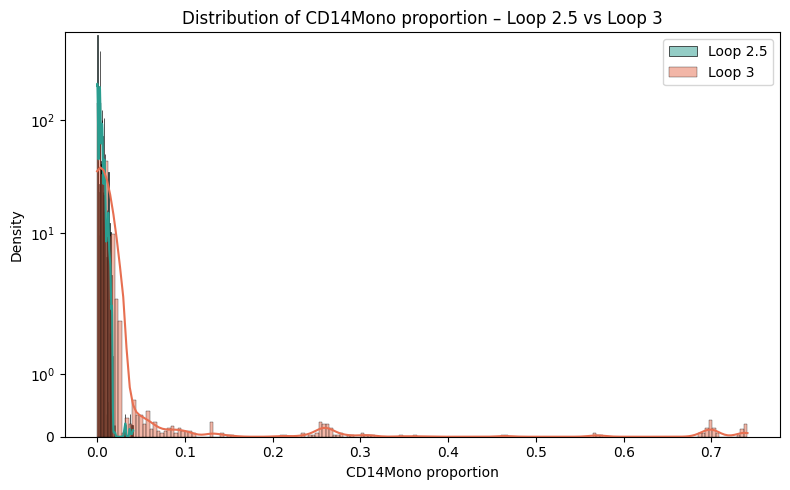

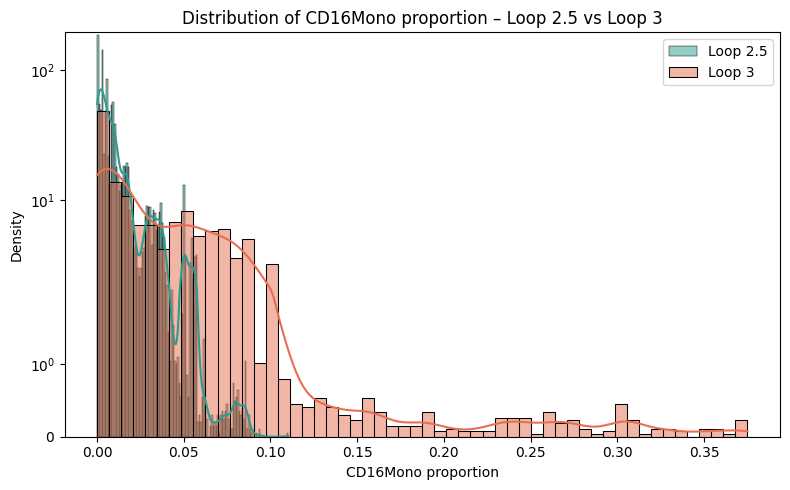

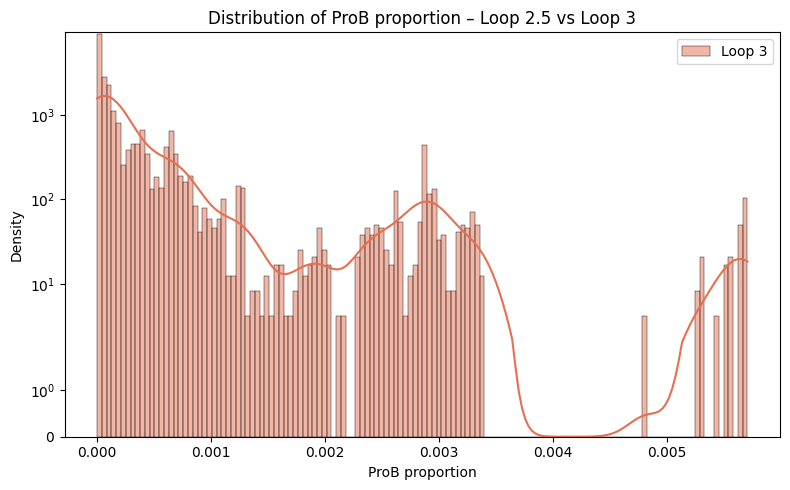

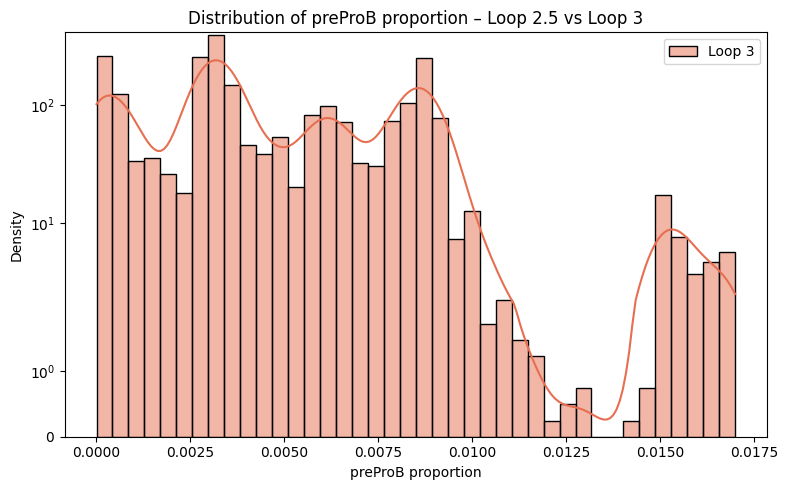

In [38]:
# Define distinct colours for the two loops
color2 = "#2a9d8f"
color3 = "#e76f51" 

for mono, ct_dfs in ct_dfs.items():
    # Extract the two DataFrames
    ct2 = ct_dfs["Loop 2.5"]
    ct3 = ct_dfs["Loop 3"]

    # Get the proportion columns
    prop2 = ct2[f"{mono}_prop"]
    prop3 = ct3[f"{mono}_prop"]

    # Create a figure and axis
    plt.figure(figsize=(8, 5))

    # Histogram + density for Loop 2.5
    sns.histplot(prop2, stat="density", kde=True,
                 color=color2, label="Loop 2.5", alpha=0.5)

    # Histogram + density for Loop 3
    sns.histplot(prop3, stat="density", kde=True,
                 color=color3, label="Loop 3", alpha=0.5)

    # Alternatively, if you prefer a pure density curve without histogram bars:
    # sns.kdeplot(prop2, color=color2, label="Loop 2.5", linewidth=2)
    # sns.kdeplot(prop3, color=color3, label="Loop 3", linewidth=2)
    plt.yscale('symlog')                    # symmetric log scale (handles zeros)

    # Add legend, labels, title
    plt.legend()
    plt.xlabel(f"{mono} proportion")
    plt.ylabel("Density")
    plt.title(f"Distribution of {mono} proportion – Loop 2.5 vs Loop 3")
    plt.tight_layout()
    plt.show()